# F05_TUOL_S1_VV_QC.ipynb
Figure 5: S1-VV QC results over Tuolumne

For additional details see ../paper_new/fig_4_tuolumne_S1_VV_QC_persistence.ipynb  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pyproj
import importlib
import sys
import rioxarray as rxr
from pathlib import Path
import xarray as xr
import contextily as ctx

# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")

In [2]:
sys.path.insert(1, '../scripts/')

In [3]:
import metadata as metadata

In [4]:
import importlib
importlib.reload(metadata)

<module 'metadata' from '/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/python/figures/../scripts/metadata.py'>

# Load Data

## Metadata

In [5]:
# tuolumne.
tuolumne_cfg = metadata.load_yaml(Path(f"../../configs/Tuolumne.yaml"))

In [6]:
importlib.reload(metadata)
# tuolumne
tuolumne_geog_fpath,aso_crs = metadata.get_shapefile_fpath(tuolumne_cfg,"shapefile_fpath","zoom_1")
# ASO
aso_cfg = metadata.load_yaml(Path(f"../../configs/ASO.yaml"))
uscatm_geog_fpath,aso_crs = metadata.get_shapefile_fpath(aso_cfg,"basin_shapefile","USCATM")
# read shapefile
## uscatm
uscatm_geog_gdf = gpd.read_file(uscatm_geog_fpath)
uscatm_proj_gdf = uscatm_geog_gdf.to_crs(f'EPSG:{aso_crs}')
## tuolumne
tuolumne_geog_gdf = gpd.read_file(tuolumne_geog_fpath)
tuolumne_proj_gdf = tuolumne_geog_gdf.to_crs(f'EPSG:{aso_crs}')

## Helper functions

In [7]:
def dem_match_bin(aso_data: xr.DataArray,
                  aso_dem: xr.DataArray,
                  bins: np.ndarray,
                  is50mSWE: bool = True,
                  isSnowModel: bool = False,
                  nan_thresh_: int = 1):
    """
    Reproject and match aso dem to aso swe grid. Create dataarray containing different
    dem grids.
    ASSUMPTIONS: three bins (low, mid, high)
    Input:
      aso_data - xarray dataarray for aso swe flights that have been subsetted.
      aso_dem - xarray dataarray for aso dem that have not been subsetted.
      bins - python list float values for left bound of mid and high bins 

    Output:
      geom_proj - geopandas object for clipped basin shape.
    """
    aso_dem_match = aso_dem
    aso_dem_match = aso_dem_match * 1
    ## assign bins ##
    bin_vals = list(bins)
    bin_vals.insert(0, float(aso_dem_match.min().values))
    bin_vals.append(float(aso_dem_match.max().values))
    if list(bins) == [5000.0,8000.0]:
      bin_labels = ['low','mid','high']
    else:
      bin_labels = [f'<{int(bins[0])}']
      for i in range(1,len(bins)):
        bin_labels.append(f'{int(bins[i-1])}-{int(bins[i])}')
      bin_labels.append(f'>{int(bins[-1])}')

    data = []
    for i in range(0,len(bin_vals)-1):
        arr = aso_dem_match.where((aso_dem_match >= bin_vals[i]) & (aso_dem_match < bin_vals[i+1])).values.reshape(1,aso_dem_match.shape[0],aso_dem_match.shape[1])
        da = xr.DataArray(
          data=arr,
          dims=["elev","y", "x"],
          coords=dict(
              elev=(["elev"], [bin_labels[i]]),
              y=(["y"], aso_dem_match["y"].values),
              x=(["x"], aso_dem_match["x"].values)
              )
         )
        data.append(da)

    arr = aso_dem_match.values.reshape(1,aso_dem_match.shape[0],aso_dem_match.shape[1])
    da = xr.DataArray(
         data=arr,
         dims=["elev","y", "x"],
         coords=dict(
             elev=(["elev"], ['total']),
             y=(["y"], aso_dem_match["y"].values),
             x=(["x"], aso_dem_match["x"].values)
            )
         )
    data.append(da)
    return xr.concat(data, dim="elev")

In [8]:
def sm_geog_curvilinear_to_rectilinear(ds,
                                       var = 'VEG',
                                       proj_string = '+proj=lcc +lat_1=30.0 +lat_2=50.0 +lat_0=39.100006 +lon_0=-97.9 +a=6370000 +b=6370000 +type=crs'):
    p = pyproj.Proj(proj_string)
    proj_x,proj_y = p(ds.XLONG.values,ds.XLAT.values,inverse = False)

    ## convert 2D lat/lon to 1D for rio reprojection and clipping ##
    lon_2v = proj_x[int(ds.XLAT.shape[0]/2),:]
    lat_2v = proj_y[:,int(ds.XLAT.shape[1]/2)]

    da = xr.DataArray(
    data = ds[var].values,
    dims = ["y","x"],
    coords = dict(
        y = (["y"], lat_2v),
        x = (["x"], lon_2v),
    )
    )
    da.name = var
    da = da.rio.write_crs(proj_string, inplace=False)
    return da

def veg_to_bins(da):
    ds = da.to_dataset()
    ## vegetation mapping ##
    ds['VEG'] = ds.VEG.astype(int)
    conditions  = [ (ds.VEG == 1) | (ds.VEG == 2) | (ds.VEG == 3) | (ds.VEG == 4) | (ds.VEG == 5), # forest
               (ds.VEG == 6) | (ds.VEG == 7) | (ds.VEG == 8) | (ds.VEG == 9) | (ds.VEG == 10) | (ds.VEG == 11), # shrub
               (ds.VEG == 12) | (ds.VEG == 13) | (ds.VEG == 14) | (ds.VEG == 15) | (ds.VEG == 16) | (ds.VEG == 17), # grass
               (ds.VEG == 18),  # bare
               (ds.VEG == 19) | (ds.VEG == 20) | (ds.VEG == 24), # water
               (ds.VEG == 21) | (ds.VEG == 22) | (ds.VEG == 23), # human
              ]
              
    choices     = [1, # forest
               2, # shrub
               3, # grass
               4, # bare
               5, # water
               6 # human
              ]
    dir_array = np.select(conditions, choices, default=np.nan)
    ds['veg_bin'] = xr.DataArray(data = dir_array,dims = ["y","x"])
    ds['veg_bin'] = ds.veg_bin.astype(int)
    return ds,choices
    

In [9]:
def add_terrain_bins_for_tuolumne_no_lia(
    terrain_ds: xr.Dataset,
    *,
    elev_bin_m=100.0,          # 100-meter elevation bins
    hgt_var="hgt",
    elev_dim="elev",
    use_total_if_present=True,
    load_to_memory=True,
) -> xr.Dataset:
    """
    Adds (NO LIA):
      - elev_bin(y,x) int16 (100-m bins)
      - elev_bin_edges

    Does NOT add lia_bin / lia_bin_edges.
    """
    ds = terrain_ds.load() if load_to_memory else terrain_ds

    # -------------------------
    # Height (y,x) from hgt
    # (your hgt sometimes stored as (elev,y,x); we want a 2D DEM)
    # -------------------------
    hgt = ds[hgt_var]
    if elev_dim in hgt.dims:
        if use_total_if_present and (elev_dim in ds.coords) and ("total" in ds.coords[elev_dim].values):
            hgt2d = hgt.sel({elev_dim: "total"})
        else:
            hgt2d = hgt.median(elev_dim, skipna=True)
    else:
        hgt2d = hgt

    # -------------------------
    # Elevation bins: 100 m
    # -------------------------
    dz = float(elev_bin_m)
    h = hgt2d.values
    hmin = np.nanmin(h)
    hmax = np.nanmax(h)
    elev_edges = np.arange(np.floor(hmin / dz) * dz, np.ceil(hmax / dz) * dz + dz, dz)

    elev_bin = (np.digitize(h, elev_edges) - 1).astype(np.int16)

    ds = ds.assign(
        elev_bin=xr.DataArray(elev_bin, dims=("y", "x"), coords={"y": ds["y"], "x": ds["x"]}),
        elev_bin_edges=xr.DataArray(elev_edges, dims=("elev_bin_edge",)),
    )

    return ds

## Terrain loading

In [10]:
sm_tuolumne_biased_fpath = metadata.get_snowmodel_fpath(tuolumne_cfg, "biased")

In [11]:
sm_tuol_ctrl_ds = xr.load_dataset(f'{sm_tuolumne_biased_fpath}wy_2017/geography/ctrl_geog.nc')
# snowmodel elevation/vegetation
veg_proj_da = sm_geog_curvilinear_to_rectilinear(sm_tuol_ctrl_ds,var = 'VEG',proj_string = '+proj=utm +zone=11 +datum=WGS84 +units=m +no_defs +type=crs')
hgt_proj_da = sm_geog_curvilinear_to_rectilinear(sm_tuol_ctrl_ds,var = 'HGT',proj_string = '+proj=utm +zone=11 +datum=WGS84 +units=m +no_defs +type=crs')

elev_arr = np.arange(2750,
                     3750,
                     200)
dem_frac = dem_match_bin(hgt_proj_da.rio.clip(tuolumne_proj_gdf.geometry),
                  hgt_proj_da.rio.clip(tuolumne_proj_gdf.geometry),
                  elev_arr,
                  is50mSWE = True,
                  isSnowModel = False,
                  nan_thresh_ = 1)

veg_proj_ds,_ = veg_to_bins(veg_proj_da)

In [12]:
terrain_ds = dem_frac[-1].to_dataset(name = 'hgt')
terrain_ds['landcover'] = veg_proj_ds["veg_bin"].rio.clip(tuolumne_proj_gdf.geometry)
terrain_mem = terrain_ds.load()

In [13]:
terrain_binned = add_terrain_bins_for_tuolumne_no_lia(
    terrain_mem,
    elev_bin_m=400,
)

## S1-VV data (2017–2020)

In [14]:

tu_vv_2017 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2017_wetness_phase.nc")
tu_vv_2018 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2018_wetness_phase.nc")
tu_vv_2019 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2019_wetness_phase.nc")
tu_vv_2020 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2020_wetness_phase.nc")

### Year-count computation

In [15]:
# Stack qc_ok as float so NaN pixels (outside basin) remain NaN
qc_stack = np.stack([ds['qc_ok'].values.astype(float)
                     for ds in [tu_vv_2017, tu_vv_2018, tu_vv_2019, tu_vv_2020]], axis=0)

# 0 = never passed QC, 4 = always passed QC
year_count = np.nansum(qc_stack, axis=0).astype(float)
year_count[np.all(np.isnan(qc_stack), axis=0)] = np.nan

unique, counts = np.unique(year_count[~np.isnan(year_count)].astype(int), return_counts=True)
print("Year count distribution:")
for u, c in zip(unique, counts):
    print(f"  {u} years: {c:,} pixels ({100*c/counts.sum():.1f}%)")

Year count distribution:
  0 years: 23,859 pixels (45.5%)
  1 years: 10,024 pixels (19.1%)
  2 years: 9,050 pixels (17.3%)
  3 years: 6,831 pixels (13.0%)
  4 years: 2,616 pixels (5.0%)


# S1-Rc QC Figure

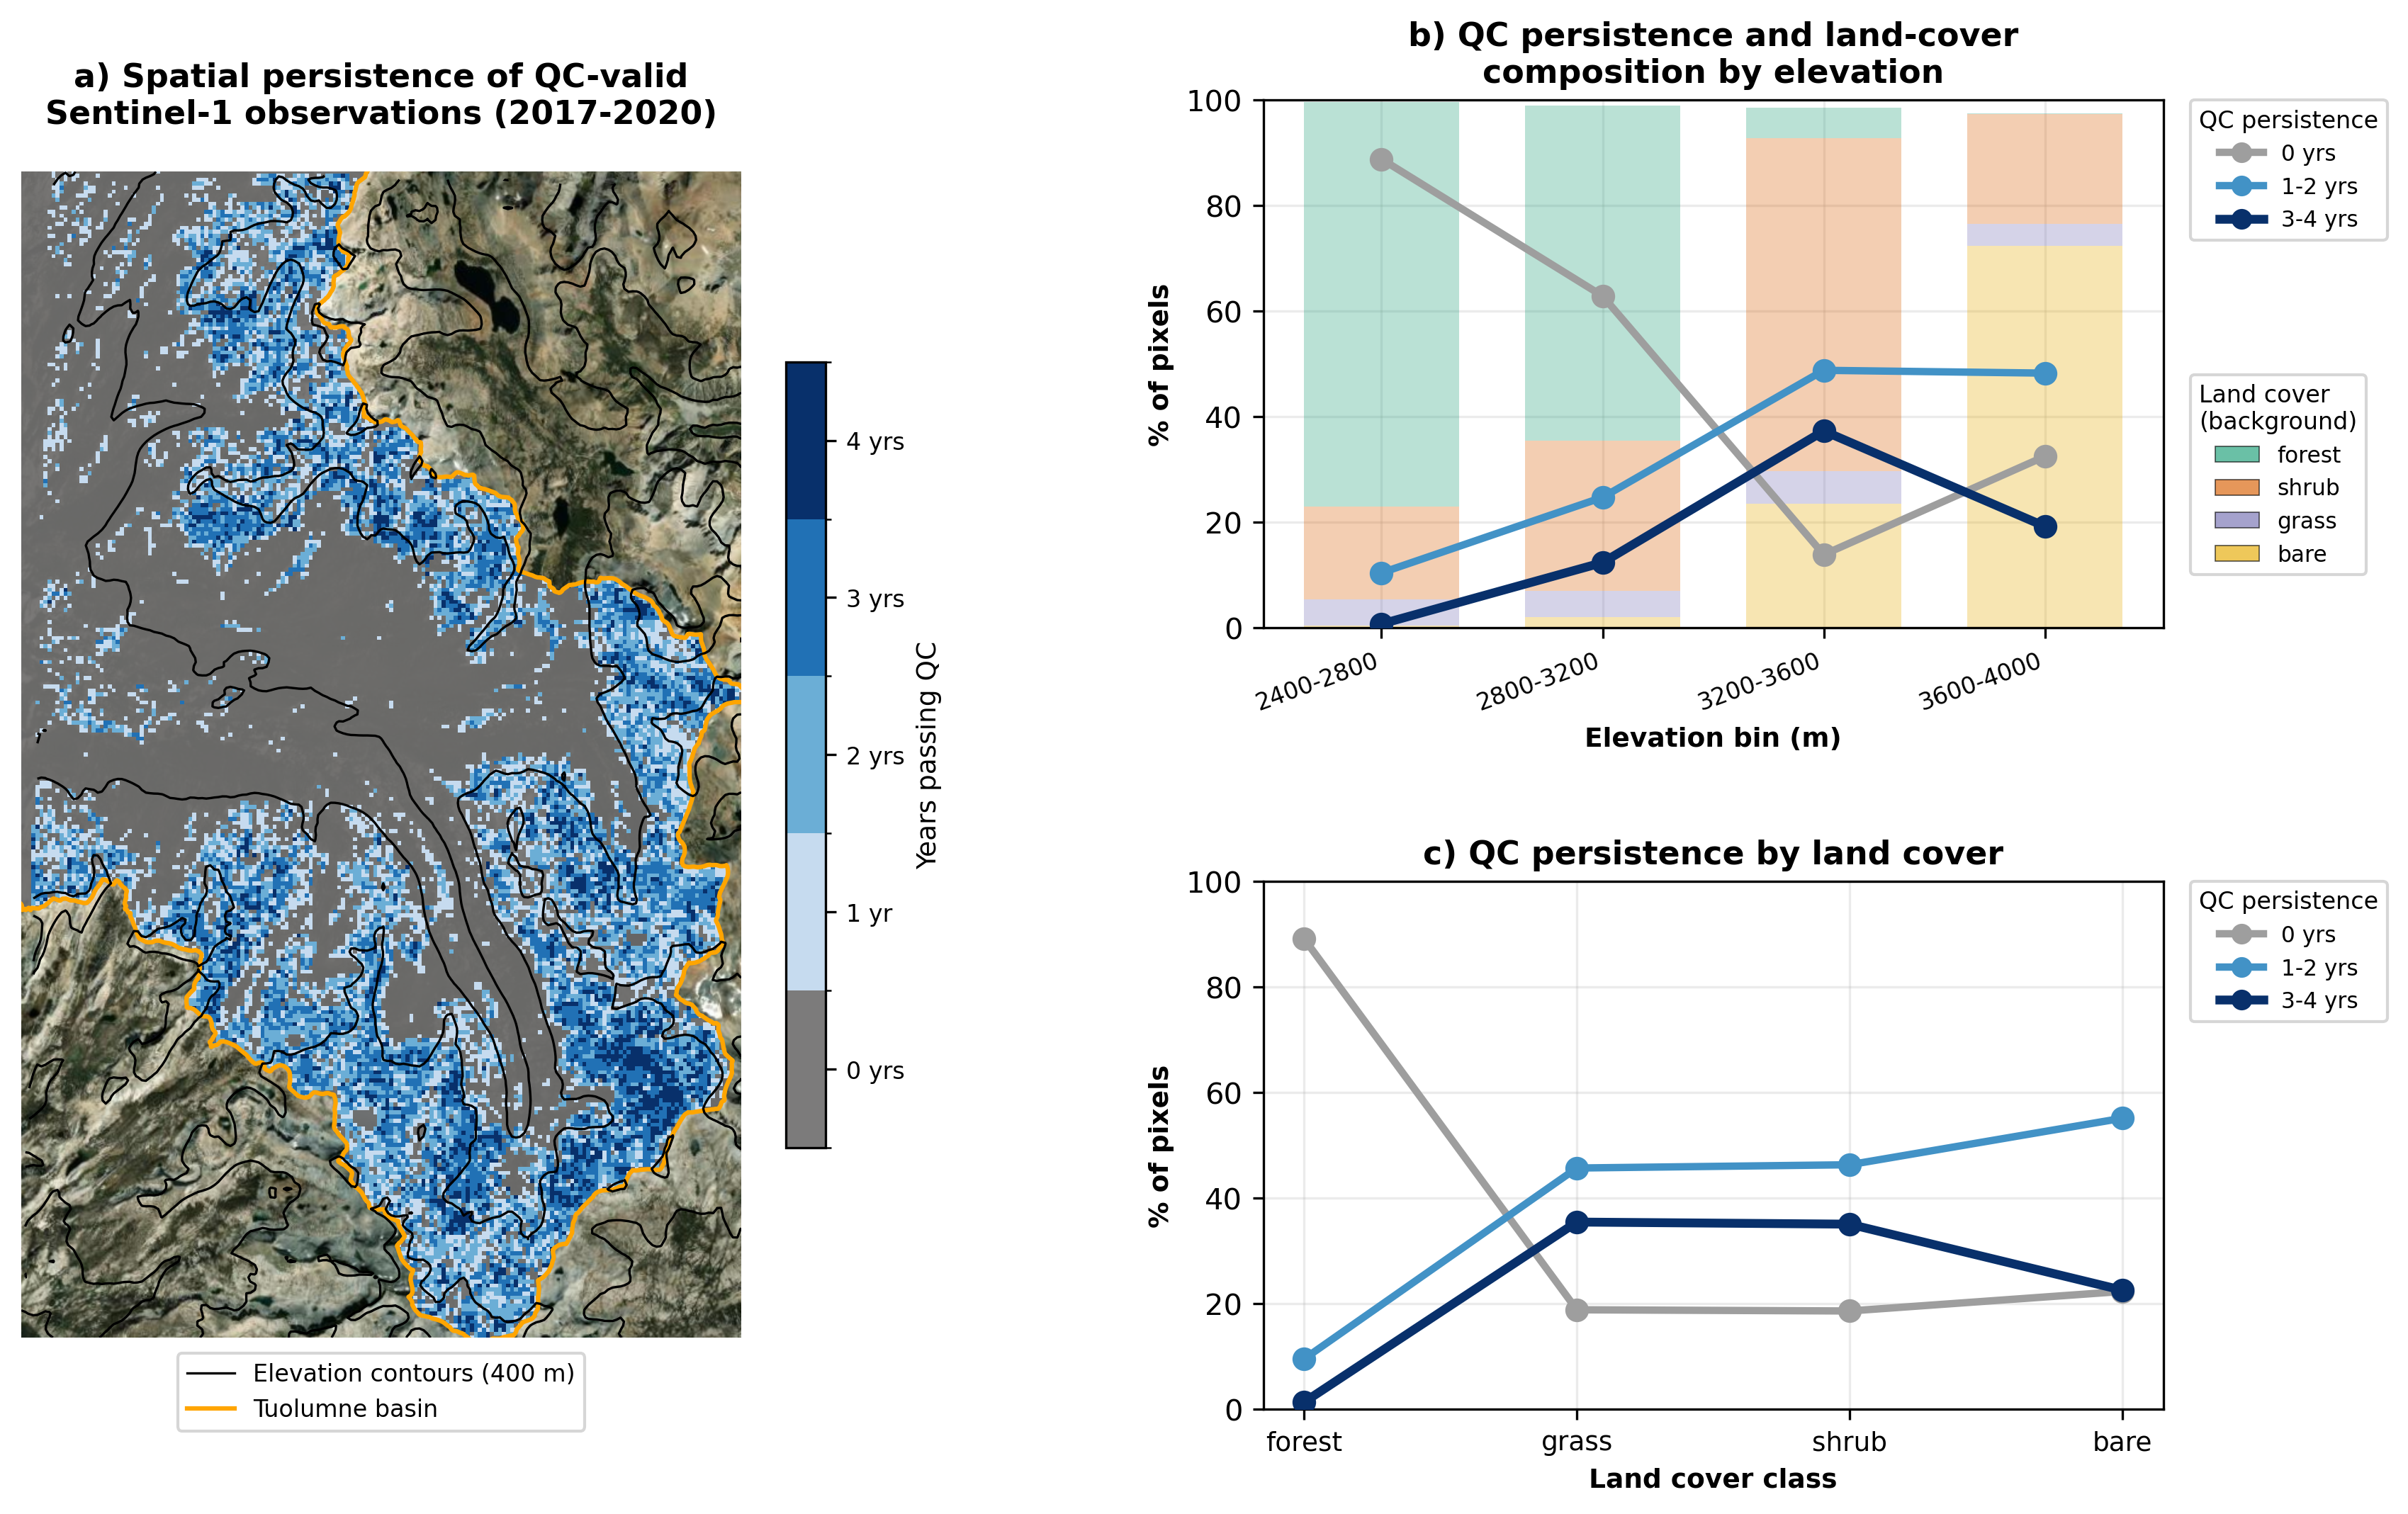

In [16]:
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterio.enums import Resampling

# ── Recompute shared arrays ────────────────────────────────────────────────────
elev_bin_da = terrain_binned["elev_bin"].rio.write_crs(f"EPSG:{aso_crs}")
year_count_da = xr.DataArray(
    year_count, dims=["y", "x"],
    coords={"y": tu_vv_2017.y.values, "x": tu_vv_2017.x.values}
).rio.write_crs(f"EPSG:{aso_crs}")

hgt_uscatm  = terrain_binned["hgt"].rio.write_crs(f"EPSG:{aso_crs}").rio.clip(
    uscatm_proj_gdf.geometry, drop=False)
uscatm_mask = np.isfinite(hgt_uscatm.values)

year_count_uscatm = year_count_da.rio.clip(
    uscatm_proj_gdf.geometry, drop=False).values
year_count_m = (
    year_count_da.rio.clip(uscatm_proj_gdf.geometry, drop=False)
    .rio.reproject_match(elev_bin_da, resampling=Resampling.nearest)
    .values
)
year_count_m[~uscatm_mask] = np.nan

elev_bin_vals = elev_bin_da.values
lc_vals       = terrain_binned["landcover"].values
target_bins   = [1, 2, 3, 4]
bin_labels    = ["2400-2800", "2800-3200", "3200-3600", "3600-4000"]

# ── QC persistence groups (3 categories, per-category linewidth) ───────────────
# (label, lo, hi, color, linewidth)
PERSIST = [
    ("0 yrs",   0, 0, "#9e9e9e", 2.5),  # never valid  — neutral gray
    ("1-2 yrs", 1, 2, "#4292c6", 2.5),  # intermittent — medium blue
    ("3-4 yrs", 3, 4, "#08306b", 3.0),  # persistent   — dark navy, thicker
]

# ── Land cover background — high-contrast palette under transparency ───────────
# Stack order: bare (bottom) → grass → shrub → forest (top)
# Colors chosen to remain visually distinct at alpha=0.30
LC_BG = [
    ("bare",   4, "#e6ab02"),  # tan
    ("grass",  3, "#7570b3"),  # light green
    ("shrub",  2, "#d95f02"),  # olive
    ("forest", 1, "#1b9e77"),  # dark green
]
ALPHA_BG = 0.30

# ── QC persistence colormap (Panel A) ─────────────────────────────────────────
COUNT_COLORS = {0: "#706f6fea", 1: "#c6dbef", 2: "#6baed6", 3: "#2171b5", 4: "#08306b"}
COUNT_LABELS = {0: "0 yrs", 1: "1 yr", 2: "2 yrs", 3: "3 yrs", 4: "4 yrs"}
cmap_count   = mcolors.ListedColormap([COUNT_COLORS[i] for i in range(5)])
bnorm        = mcolors.BoundaryNorm(np.arange(-0.5, 5, 1), cmap_count.N)

TITLE_FS = 11
LBL_FS   = 9
LW_BASIN = 1.5
LEG_FS   = 7.5    # legend font size
LEG_TFS  = 8.0    # legend title font size
LEG_X    = 1.03   # bbox_to_anchor x for outside-axes legends

# ── Layout ─────────────────────────────────────────────────────────────────────
fig = plt.figure(dpi=300, figsize=(13, 8))   # extra width for right-margin legends
gs  = gridspec.GridSpec(2, 2, figure=fig, wspace=0.38, hspace=0.48)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

# ══════════════════════════════════════════════════════════════════════════════
# Panel A — QC persistence spatial map (USCATM basin)
# ══════════════════════════════════════════════════════════════════════════════
xx_vv, yy_vv = np.meshgrid(tu_vv_2017.x.values, tu_vv_2017.y.values)
ax1.set_xlim(xx_vv.min(), xx_vv.max())
ax1.set_ylim(yy_vv.min(), yy_vv.max())

ctx.add_basemap(ax=ax1, crs=aso_crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
pcm = ax1.pcolormesh(xx_vv, yy_vv, year_count_uscatm, cmap=cmap_count, norm=bnorm,
                     rasterized=True, zorder=2)
uscatm_proj_gdf.plot(ax=ax1, color="none", edgecolor="orange", linewidth=LW_BASIN, zorder=5)
hgt_clip = hgt_proj_da.rio.clip(tuolumne_proj_gdf.geometry)
ax1.contour(hgt_clip.x.values, hgt_clip.y.values, hgt_clip.values,
            levels=[2400, 2800, 3200, 3600, 4000],
            colors="black", linewidths=0.8, zorder=6)
ax1.set_title(
    "a) Spatial persistence of QC-valid\nSentinel-1 observations (2017-2020)",
    fontweight="bold", fontsize=TITLE_FS)
ax1.axis("off")
ax1.set_aspect("equal")
cbar = fig.colorbar(pcm, ax=ax1, ticks=range(5), shrink=0.6)
cbar.ax.set_yticklabels([COUNT_LABELS[i] for i in range(5)], fontsize=8)
cbar.set_label("Years passing QC", fontsize=9)

# ── Shared map legend (below Panel A) ─────────────────────────────────────────
map_handles = [
    Line2D([0],[0], color="black", linewidth=0.8, label="Elevation contours (400 m)"),
    Line2D([0],[0], color="orange", linewidth=LW_BASIN, label="Tuolumne basin"),
]
ax1.legend(handles=map_handles, fontsize=8, frameon=True,
           loc="lower center", bbox_to_anchor=(0.5, -0.09), ncol=1)

# ══════════════════════════════════════════════════════════════════════════════
# Panel B — QC persistence vs elevation + land-cover composition (background)
# ══════════════════════════════════════════════════════════════════════════════
ax2.set_axisbelow(True)

# Background: stacked bars — LC fraction per elevation bin
bottoms = np.zeros(len(target_bins))
for lc_name, lc_code, lc_color in LC_BG:
    heights = np.array([
        100 * np.sum((lc_vals == lc_code) & (elev_bin_vals == b) & uscatm_mask)
        / max(np.sum((elev_bin_vals == b) & uscatm_mask), 1)
        for b in target_bins
    ])
    ax2.bar(range(len(bin_labels)), heights, bottom=bottoms,
            color=lc_color, alpha=ALPHA_BG, width=0.7, zorder=1, edgecolor="none")
    bottoms += heights

# Foreground: QC persistence lines
for label, lo, hi, color, lw in PERSIST:
    pcts = np.array([
        100 * np.nansum(
            (year_count_m[(elev_bin_vals == b) & uscatm_mask] >= lo) &
            (year_count_m[(elev_bin_vals == b) & uscatm_mask] <= hi)
        ) / max(np.sum((elev_bin_vals == b) & uscatm_mask), 1)
        for b in target_bins
    ])
    ax2.plot(range(len(bin_labels)), pcts, color=color, marker="o",
             markersize=7, linewidth=lw, zorder=3)

ax2.set_xticks(range(len(bin_labels)))
ax2.set_xticklabels(bin_labels, rotation=20, ha="right", fontsize=8)
ax2.set_xlabel("Elevation bin (m)", fontweight="bold", fontsize=LBL_FS)
ax2.set_ylabel("% of pixels", fontweight="bold", fontsize=LBL_FS)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.25)
ax2.set_title("b) QC persistence and land-cover\ncomposition by elevation",
              fontweight="bold", fontsize=TITLE_FS)

# Legends outside axes — stacked vertically on the right margin
qc_handles = [
    Line2D([0],[0], color=c, linewidth=lw, marker="o", markersize=6, label=lbl)
    for lbl, lo, hi, c, lw in PERSIST
]
lc_bg_handles = [
    Patch(facecolor=c, alpha=0.65, edgecolor="k", linewidth=0.4, label=n)
    for n, _, c in reversed(LC_BG)  # forest at top of legend = top of stack
]

leg_b1 = ax2.legend(handles=qc_handles, title="QC persistence",
                    fontsize=LEG_FS, title_fontsize=LEG_TFS, frameon=True,
                    loc="upper left", bbox_to_anchor=(LEG_X, 1.0),
                    borderaxespad=0)
ax2.add_artist(leg_b1)
ax2.legend(handles=lc_bg_handles, title="Land cover\n(background)",
           fontsize=LEG_FS, title_fontsize=LEG_TFS, frameon=True,
           loc="upper left", bbox_to_anchor=(LEG_X, 0.48),
           borderaxespad=0)

# ══════════════════════════════════════════════════════════════════════════════
# Panel C — QC persistence by land cover (forest → grass → shrub → bare)
# ══════════════════════════════════════════════════════════════════════════════
lc_cats_c = [("forest", 1), ("grass", 3), ("shrub", 2), ("bare", 4)]
lc_lbls_c = [lc[0] for lc in lc_cats_c]

ax3.set_axisbelow(True)

for label, lo, hi, color, lw in PERSIST:
    pcts = np.array([
        100 * np.nansum(
            (year_count_m[(lc_vals == code) & uscatm_mask] >= lo) &
            (year_count_m[(lc_vals == code) & uscatm_mask] <= hi)
        ) / max(np.sum((lc_vals == code) & uscatm_mask), 1)
        for _, code in lc_cats_c
    ])
    ax3.plot(range(len(lc_lbls_c)), pcts, color=color, marker="o",
             markersize=7, linewidth=lw, label=label, zorder=3)

ax3.set_xticks(range(len(lc_lbls_c)))
ax3.set_xticklabels(lc_lbls_c, fontsize=9)
ax3.set_xlabel("Land cover class", fontweight="bold", fontsize=LBL_FS)
ax3.set_ylabel("% of pixels", fontweight="bold", fontsize=LBL_FS)
ax3.set_ylim(0, 100)
ax3.grid(True, alpha=0.25)
ax3.set_title("c) QC persistence by land cover",
              fontweight="bold", fontsize=TITLE_FS)

# Legend outside axes — right margin, aligned with Panel B
ax3.legend(handles=qc_handles, title="QC persistence",
           fontsize=LEG_FS, title_fontsize=LEG_TFS, frameon=True,
           loc="upper left", bbox_to_anchor=(LEG_X, 1.0),
           borderaxespad=0)

plt.tight_layout()
plt.savefig("./pngs/F07_TUOL_S1_VV_QC.png", dpi=300, bbox_inches="tight")
plt.show()
